# Symbolic computation
Symbolic computation can be used to simplify equation before using numerical methods.

In [1]:
import sympy
sympy.init_printing()
print('SymPy version: {}'.format(sympy.__version__))

SymPy version: 1.14.0


## Variables
We create an abstract symbol x without information about it

In [2]:
x = sympy.Symbol("x")
x

In [3]:
y = sympy.Symbol("y", real=True)

In [4]:
y.is_real

True

In [5]:
x.is_real is True

False

In [6]:
x.is_real is False

False

In [7]:
x.is_real is None

True

In [8]:
y = sympy.Symbol("y", positive=True)

Since no information about the symbol x is avialable no computation can be done with it 

In [9]:
sympy.sqrt(x ** 2)

Since y is a real positive number the symbolic computation can be performed

In [10]:
sympy.sqrt(y ** 2)

We can instantiate several symbols with one instruction

In [11]:
a, b, c = sympy.symbols("a, b, c", negative=True)
a

In [12]:
a.is_real

True

## Functions

In [24]:
x, y, z = sympy.symbols("x, y, z")

A function without a body is undefined

In [25]:
f = sympy.Function("f")
type(f)

sympy.core.function.UndefinedFunction

In [26]:
g = sympy.Function("g")(x, y, z)
g

In [28]:
g.free_symbols

In [32]:
x = 1/2 * sympy.pi
x

In [33]:
sympy.sin(x)

We can define lambda functions, that is, functions without name

In [38]:
h = sympy.Lambda(z, z**2)
h

In [39]:
h(3)

## Expressions
A mathematical expression is represented as a tree where the operators are the nodes and the variables are the leaves.

In [2]:
x = sympy.Symbol("x")
expr = 1 + 2 * x**2 + 3 * x**3
expr

In [3]:
expr.args

In [7]:
expr.args[1].args[1].args

In [11]:
sympy.srepr(expr)

"Add(Mul(Integer(3), Pow(Symbol('x'), Integer(3))), Mul(Integer(2), Pow(Symbol('x'), Integer(2))), Integer(1))"

### Simplification

In [12]:
expr = 2 * (x**2 - x) - x * (x + 1)
expr

In [14]:
expr.simplify()

### Expansion

In [15]:
expr = (x + 1) * (x + 2)
expr

In [16]:
expr.expand()

## Calculus
Calculus is about computing derivatives and integrals. Series expansion, e.g. Taylor's or Fourier's, and limits are also relevant subjects for function approximation and asymptotic evaluation.

### Derivatives
A derivative represents the rate of change of a variable. We start with the 1st derivative

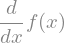

In [4]:
x = sympy.Symbol('x')
f = sympy.Function('f')(x)
sympy.diff(f, x)

To define the second derivative we just add the order as a 3rd argument

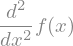

In [5]:
sympy.diff(f, x, 2)

The process is similar for multivariate functions. In this case we deal with *partial derivatives*.

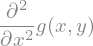

In [8]:
x = sympy.Symbol('x')
y = sympy.Symbol('y')
g = sympy.Function('g')(x, y)
g.diff(x, 2, y, 0)

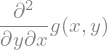

In [9]:
g.diff(x, 1, y, 1)

The derivative of a polynomial is straigthforward

In [11]:
expr = x**4 + x**3 + x**2 + x + 1
expr

In [12]:
expr.diff(x)

We may want to compute successive derivatives of an expresion

In [19]:
x = sympy.Symbol('x')
y = sympy.Symbol('y')
z = sympy.Symbol('z')
expr = (x + 1)**3 * y ** 2 * (z - 1)
dx = expr.diff(x)
dx

In [21]:
dy = dx.diff(y)
dy

In [23]:
dz = dy.diff(z)
dz

or all the steps in one function call

In [24]:
expr.diff(x, y, z)

### Integrals
The integral of a function indefinite or definite. In the first case the result is a function whose derivative is the integrand. In the second case the result of the integration is a number, the integral of a function over a defined interval [a,b]. We start by defining the variables and the function

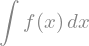

In [28]:
x = sympy.symbols('x')
f = sympy.Function('f')(x)
sympy.integrate(f)

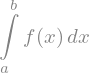

In [29]:
a, b = sympy.symbols('a, b')
sympy.integrate(f, (x, a, b))

In [30]:
expr = x
sympy.integrate(expr)

In [34]:
sympy.integrate(expr, (x, 0, 1))

### Series
We can compute the 3rd order expansion of a function $f(x)$ at a point $\xi$

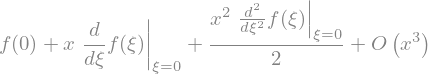

In [44]:
x = sympy.symbols('x')
f = sympy.Function('f')(x)
f.series(x, n=3)

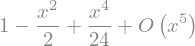

In [48]:
sympy.cos(x).series(n=5)

We may want to calculate the sum of a series

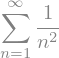

In [52]:
n = sympy.symbols('n', integer=True)
s = sympy.Sum(1/(n**2), (n, 1, sympy.oo))
s

In [53]:
s.doit()

### Limits

In [49]:
sympy.limit(sympy.sin(x) / x, x, 0)

## Equations
Equations that can be solved by symbolic calculation are called analytical equations. Solving an equation $y=f(x)$ means finding the roots of $f(x)=0$ 

In [54]:
x = sympy.Symbol('x')
y = x**2 + 2*x - 3
sympy.solve(y)

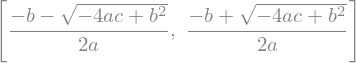

In [55]:
a, b, c = sympy.symbols('a, b, c')
sympy.solve(a * x**2 + b * x + c, x)

We can solve a system of linear equations

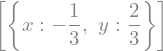

In [58]:
x = sympy.Symbol('x')
y = sympy.Symbol('y')
eq1 = x + 2 * y - 1
eq2 = x - y + 1
sympy.solve([eq1, eq2], [x, y], dict=True)

## Linear algebra
We can define vectors and matrices

In [68]:
sympy.Matrix([[1, 2]])

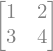

In [69]:
A = sympy.Matrix([[1, 2],[3, 4]])
A

We can apply several operators such transpose

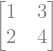

In [71]:
A.T

compute the trace of a matrix

In [76]:
A.trace()

Compute the determinant

In [75]:
sympy.det(A)

and the inverse

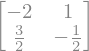

In [78]:
A.inv()

We can perform matrix multiplication (the dot operator in NUmPy)

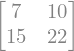

In [70]:
A * A

We can perform the same operation on symbolic matrices

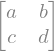

In [66]:
a, b, c, d = sympy.symbols('a, b, c, d')
M = sympy.Matrix([[a, b], [c, d]])
M

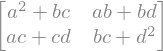

In [67]:
M * M